<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [5]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [6]:
df['Industry'].value_counts().head(10)


Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64

/tmp/ipykernel_2175/3067461071.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=industry_counts.index, y=industry_counts.values, palette="pastel")


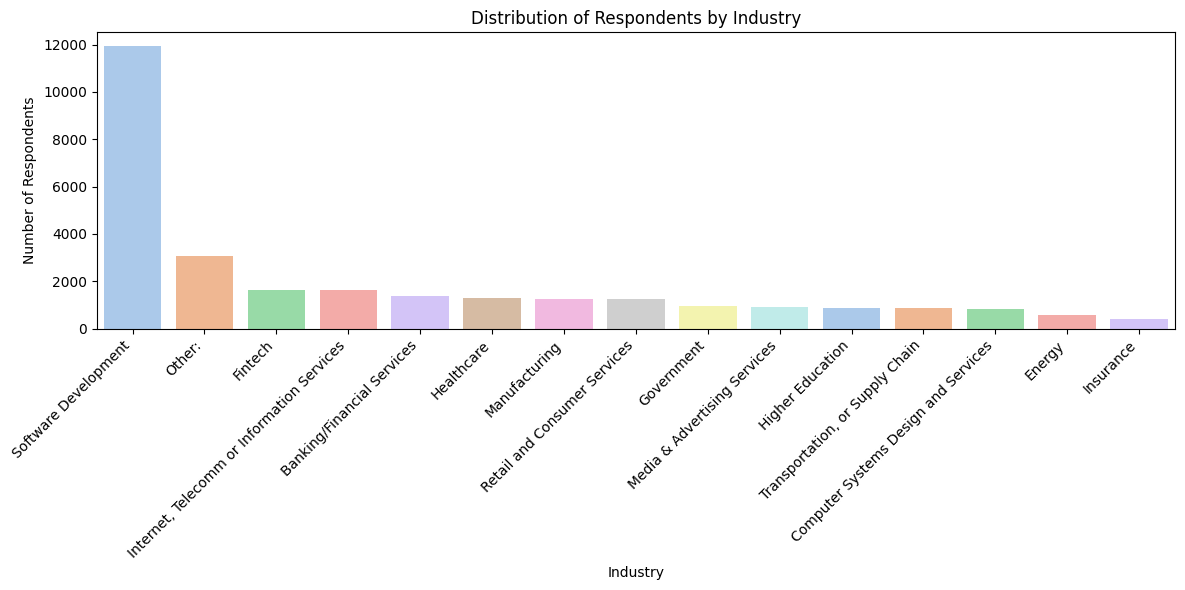

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count respondents per industry
industry_counts = df['Industry'].value_counts().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(12,6))
sns.barplot(x=industry_counts.index, y=industry_counts.values, palette="pastel")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Industry")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Respondents by Industry")
plt.tight_layout()
plt.show()


<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [8]:
# Ensure numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Drop missing values
comp_df = df['ConvertedCompYearly'].dropna()

# Basic statistics
mean_comp = comp_df.mean()
median_comp = comp_df.median()
std_comp = comp_df.std()

print(f"Mean compensation: ${mean_comp:,.2f}")
print(f"Median compensation: ${median_comp:,.2f}")
print(f"Standard deviation: ${std_comp:,.2f}")


Mean compensation: $86,155.29
Median compensation: $65,000.00
Standard deviation: $186,756.97


In [9]:
threshold = mean_comp + 3 * std_comp
print(f"High compensation threshold: ${threshold:,.2f}")


High compensation threshold: $646,426.21


In [12]:
high_comp = df[df['ConvertedCompYearly'] > threshold]

print(f"Number of high compensation outliers: {len(high_comp)}")

# Show top 10 high earners
high_comp[['ConvertedCompYearly', 'Country', 'JobSat']].head(10)



Number of high compensation outliers: 89


,ConvertedCompYearly,Country,JobSat
529,650000.0,United States of America,6.0
828,1000000.0,United States of America,8.0
1932,945000.0,United States of America,2.0
2171,750000.0,United States of America,8.0
2187,2000000.0,Gabon,NaN
2316,1000000.0,United States of America,10.0
2592,800000.0,United States of America,8.0
3024,1302817.0,Kazakhstan,NaN
5934,1031099.0,Germany,NaN
6735,650000.0,United States of America,8.0


In [13]:
high_comp_sorted = high_comp.sort_values(by='ConvertedCompYearly', ascending=False)
high_comp_sorted[['ConvertedCompYearly', 'Country', 'JobSat']].head(10)


,ConvertedCompYearly,Country,JobSat
15837,16256603.0,Ethiopia,NaN
12723,13818022.0,South Africa,10.0
28379,9000000.0,Taiwan,10.0
17593,6340564.0,Brazil,6.0
17672,4936778.0,Ukraine,7.0
19267,3367716.0,India,7.0
23694,2584118.0,Pakistan,NaN
33720,2237846.0,Brazil,NaN
34523,2153432.0,Pakistan,10.0
13763,2048046.0,Australia,10.0


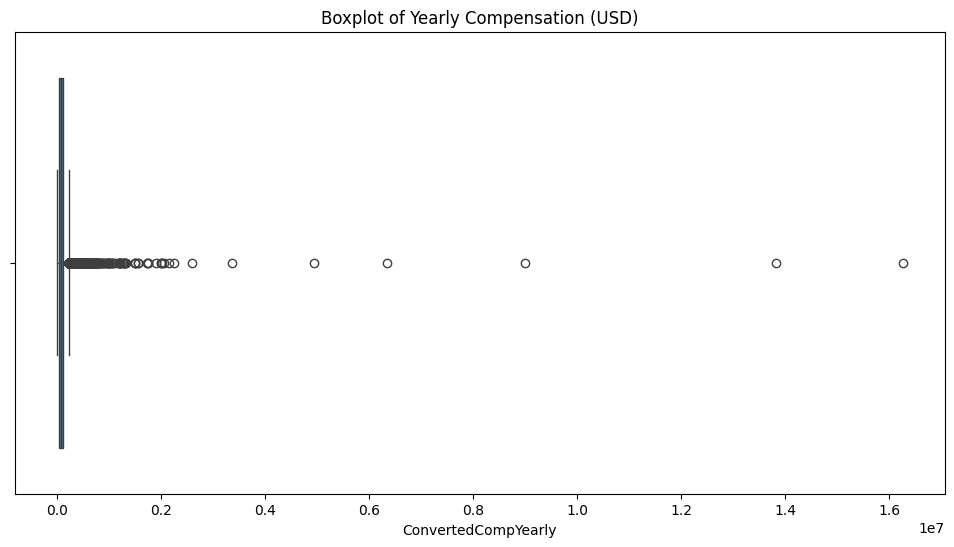

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x=comp_df)
plt.title("Boxplot of Yearly Compensation (USD)")
plt.xlabel("ConvertedCompYearly")
plt.show()


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [14]:
# Convert to numeric (if not already) and drop missing values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
comp_df = df['ConvertedCompYearly'].dropna()


In [15]:
# Calculate Q1 and Q3
Q1 = comp_df.quantile(0.25)
Q3 = comp_df.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: ${Q1:,.2f}, Q3: ${Q3:,.2f}, IQR: ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}, Upper bound: ${upper_bound:,.2f}")


Q1: $32,712.00, Q3: $107,971.50, IQR: $75,259.50
Lower bound: $-80,177.25, Upper bound: $220,860.75


In [16]:
outliers = comp_df[(comp_df < lower_bound) | (comp_df > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

# Show top 10 highest compensation outliers
outliers.sort_values(ascending=False).head(10)


Number of outliers detected: 978


15837    16256603.0
12723    13818022.0
28379     9000000.0
17593     6340564.0
17672     4936778.0
19267     3367716.0
23694     2584118.0
33720     2237846.0
34523     2153432.0
13763     2048046.0
Name: ConvertedCompYearly, dtype: float64

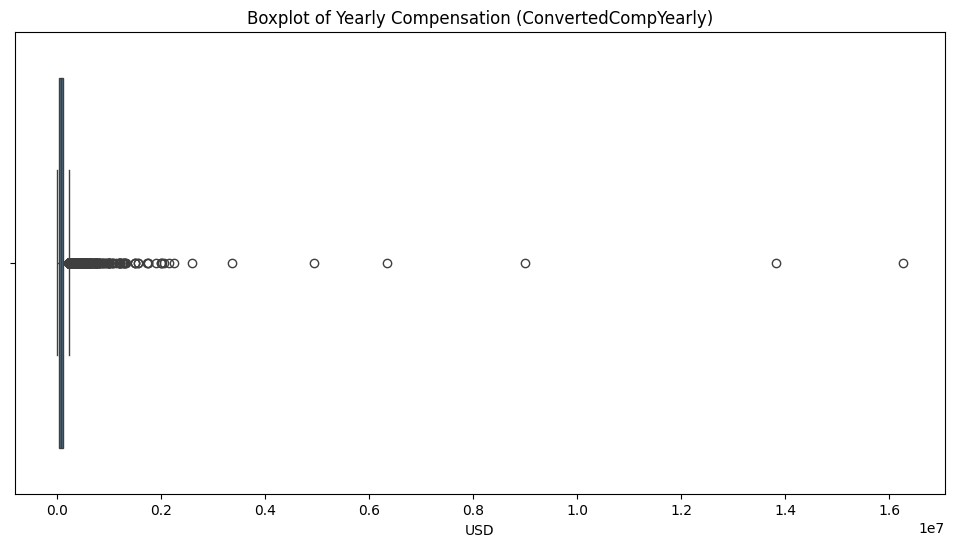

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x=comp_df)
plt.title("Boxplot of Yearly Compensation (ConvertedCompYearly)")
plt.xlabel("USD")
plt.show()


<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [18]:
# Keep only rows within the IQR bounds
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

# Check the shape of the new DataFrame
print(f"Original dataset size: {df.shape[0]} rows")
print(f"Dataset without outliers: {df_no_outliers.shape[0]} rows")


Original dataset size: 65437 rows
Dataset without outliers: 22457 rows


In [19]:
# Quick check on basic statistics
df_no_outliers['ConvertedCompYearly'].describe()


count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [20]:
# Define age mapping
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

# Apply mapping
df['Age_numeric'] = df['Age'].map(age_mapping)


In [21]:
# Select all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Include Age_numeric
numeric_cols = numeric_cols.union(['Age_numeric'])

numeric_df = df[numeric_cols].dropna()


In [22]:
# Correlation matrix
corr_matrix = numeric_df.corr()

# Focus on correlations with Age
age_corr = corr_matrix['Age_numeric'].sort_values(ascending=False)
print("Correlation of Age with other numeric variables:")
print(age_corr)


Correlation of Age with other numeric variables:
Age_numeric            1.000000
WorkExp                0.846450
ConvertedCompYearly    0.132865
JobSat                 0.070704
CompTotal             -0.012734
ResponseId            -0.035125
JobSatPoints_1        -0.041301
JobSatPoints_8        -0.058914
JobSatPoints_6        -0.059431
JobSatPoints_4        -0.077472
JobSatPoints_7        -0.093071
JobSatPoints_9        -0.093624
JobSatPoints_5        -0.102994
JobSatPoints_11       -0.113144
JobSatPoints_10       -0.119652
Name: Age_numeric, dtype: float64


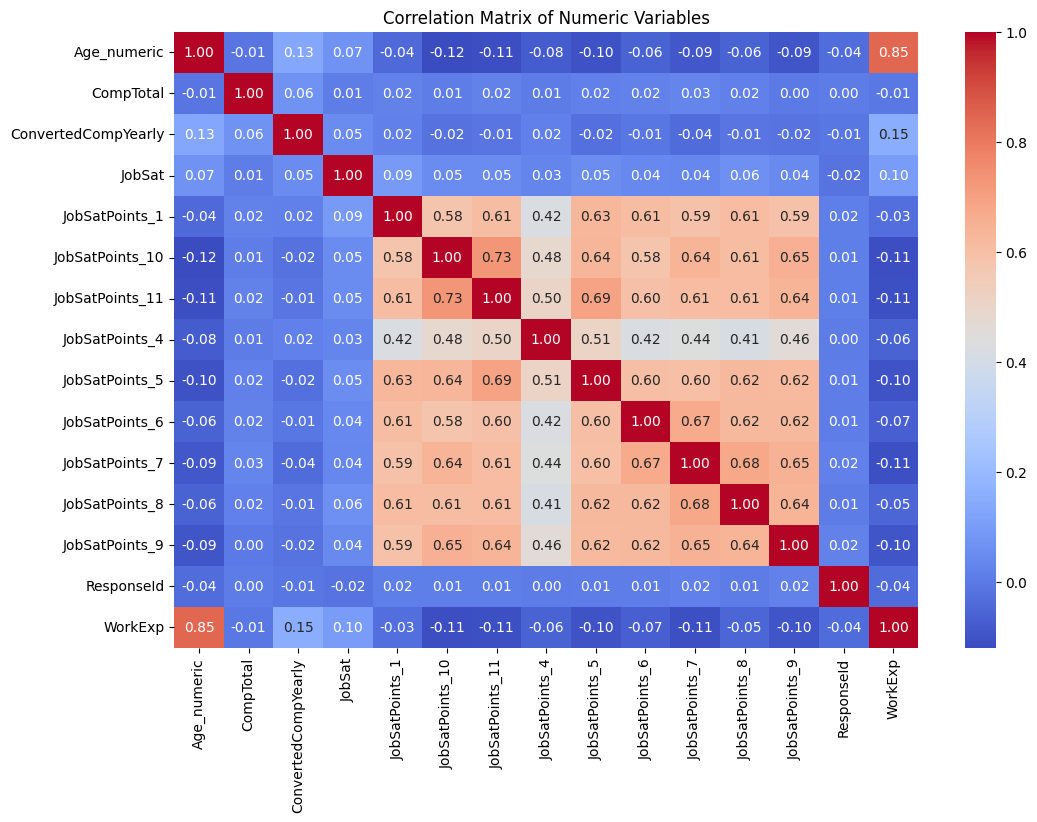

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
